# 03 — Empirical Force Fields, PBC & Minimum Image Convention

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppt-2/Ch121a-DFT/blob/main/Module%202%20-%20Molecular%20dynamics/notebooks/03_force_fields_and_pbc.ipynb)

**Ch121a: Molecular Dynamics — Caltech**  
This notebook covers the major empirical force fields (FF) used in molecular simulation, the theory and implementation of Periodic Boundary Conditions (PBC), the Minimum Image Convention (MIC), and neighbor-list algorithms.

## Learning Objectives
1. Physical approximations behind empirical FFs.
2. UFF, OPLS, AMBER, and CHARMM: scope, charge method, and use case.
3. Periodic boundary conditions.
4. Minimum image convention.
5. Verlet and cell-list neighbor algorithms and their O(N) scaling.


In [2]:
# Ch121a: Molecular Dynamics — Notebook 03: Force Fields, PBC & Minimum Image Convention
# License: GPL-3.0 (https://www.gnu.org/licenses/gpl-3.0.en.html)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
})
print('Libraries loaded.')

Libraries loaded.


---
## Section 1 — Empirical Force Fields

### 1.1 Force Field Philosophy

An **empirical force field (FF)** is a classical potential energy function whose parameters are fitted to experimental data or high-level quantum-mechanical calculations.  It rests on two key approximations:

1. **Born–Oppenheimer approximation** — electrons are infinitely fast; the nuclear configuration alone determines the potential energy surface.
2. **Classical nuclei approximation** — nuclei obey Newton's equations; quantum nuclear effects (zero-point energy, tunnelling) are neglected.

The total potential energy is partitioned:

$$U_\text{total} = U_\text{bonded} + U_\text{nonbonded}$$

where

$$U_\text{bonded} = U_\text{bond} + U_\text{angle} + U_\text{dihedral} + U_\text{improper}$$

$$U_\text{nonbonded} = U_\text{LJ} + U_\text{Coulomb}$$

**Transferability vs. accuracy trade-off:** parameters derived on small molecules may not perfectly reproduce condensed-phase properties; specialised FFs sacrifice coverage for accuracy.


### 1.2 UFF — Universal Force Field

**Reference:** Rappé, A. K. *et al.* *J. Am. Chem. Soc.* **114**, 10024 (1992).

UFF covers **every element** in the periodic table using rules-based parameter generation from atomic properties:

| Property | Symbol | Role |
|---|---|---|
| Atomic radius | $r_I$ | equilibrium bond length |
| Electronegativity (Allred–Rochow) | $\chi_I$ | partial charge |
| Hybridization | $\lambda_I$ | angle / torsion |
| Valence | $V_I$ | bond order correction |

**Equilibrium bond length** between atoms *I* and *J*:

$$r_{IJ}^0 = r_I + r_J + r_\text{BO} - r_\text{EN}$$

where $r_\text{BO} = -0.1332(r_I+r_J)\ln(n_{IJ})$ is the bond-order correction ($n_{IJ}$ = bond order) and $r_\text{EN} = r_I r_J (\sqrt{\chi_I}-\sqrt{\chi_J})^2/(\chi_I r_I + \chi_J r_J)$.

**Use cases:** metal–organic frameworks (MOFs), inorganic / organometallic systems, unusual elements not covered by organic FFs.  
**Limitations:** less accurate than OPLS/AMBER for organic liquids and drug-like molecules.


### 1.3 OPLS — Optimized Potentials for Liquid Simulations

**Developed by:** Jorgensen *et al.* (Yale).  
**Optimization target:** reproduce experimental **liquid density** ($\rho$) and **enthalpy of vaporisation** ($\Delta H_\text{vap}$) of pure organic liquids.

**Variants:**
- **OPLS-UA** (united atom): CH$_x$ treated as a single site — fast but less accurate for branching.
- **OPLS-AA** (all-atom): every heavy atom and polar H explicit.
- **OPLS/2005, OPLS3e, OPLS4** — extended coverage using ML-augmented torsion fitting.

**Charge derivation:** CM1A charges scaled by 1.14 (*1.14\*CM1A-LBCC*) to capture condensed-phase polarisation without explicit polarisability.

**Strengths:** excellent for drug-like molecules, lipid bilayers, organic solvents, proteins (OPLS3e / OPLS4 competitive with AMBER ff14SB).

**Non-bonded functional form (LJ + Coulomb):**

$$U_{ij} = 4\epsilon_{ij}\left[\left(\frac{\sigma_{ij}}{r_{ij}}\right)^{12} - \left(\frac{\sigma_{ij}}{r_{ij}}\right)^{6}\right] + \frac{q_i q_j}{4\pi\epsilon_0 r_{ij}}$$

1–4 interactions scaled by $f_{LJ}=0.5$ and $f_q=0.5$.


### 1.4 AMBER Force Field

**Full name:** Assisted Model Building with Energy Refinement.  
**Primary focus:** proteins and nucleic acids.

**Key parameter sets:**
| Set | Target system |
|---|---|
| ff14SB | proteins (2015) |
| ff19SB | proteins, updated backbone torsions |
| GAFF / GAFF2 | general organic small molecules |
| OL15 / OL21 | DNA & RNA |
| LIPID17 | lipid bilayers |

**Charge model — RESP (Restrained ElectroStatic Potential):**  
Quantum ESP (HF/6-31G*) computed, then atom-centred charges fitted with a hyperbolic restraint to prevent buried atoms from acquiring unrealistically large charges:

$$\chi^2_\text{RESP} = \sum_k\left(V_k^\text{QM} - V_k^\text{fit}\right)^2 + a\sum_i\left(\sqrt{q_i^2+b^2}-b\right)$$

**Functional form:** harmonic bonds and angles, cosine torsions, LJ + Coulomb non-bonded.  
1–4 scaling: $f_\text{LJ}=0.5$, $f_q=1/1.2$.


### 1.5 CHARMM Force Field

**Full name:** Chemistry at HARvard Macromolecular Mechanics.

**Key parameter sets:**
| Set | Target |
|---|---|
| CHARMM36 / C36m | proteins |
| CHARMM36 lipids | lipid bilayers |
| CHARMM36 NA | nucleic acids |
| CGenFF | drug-like / general organic molecules |

**Distinguishing features:**
- **Urey–Bradley term:** adds a 1,3-interaction harmonic term between atoms separated by two bonds, improving angle vibration frequencies.
- **CMAP correction:** 2D torsion correction map (φ/ψ dihedral surface) for protein backbone.
- **CHARMM-GUI:** web interface for automated FF assignment and system builder.

**Charge derivation:** MP2/6-31G* target ESP, then iterative manual adjustment to reproduce interaction energies with TIP3P water.

**vs AMBER:** both use similar functional forms; CHARMM adds Urey–Bradley and CMAP; AMBER charges from RESP (automated), CHARMM from manual optimisation.


### 1.6 Force Field Comparison Table

| Force Field | Scope | Charge Method | Validation Target | Typical Use Case |
|---|---|---|---|---|
| **UFF** | Full periodic table (entire PT) | Gasteiger / QEq | Bond lengths, angles (CSD) | MOFs, inorganic, unusual elements |
| **OPLS-AA** | Organic molecules, proteins | 1.14\*CM1A-LBCC | Liquid density, ΔH$_\text{vap}$ | Drug-like molecules, organic solvents |
| **AMBER** | Proteins, nucleic acids, small mol. | RESP (HF/6-31G*) | NMR structures, free energies | Proteins, nucleic acids, GAFF for ligands |
| **CHARMM** | Proteins, lipids, nucleic acids | MP2/6-31G* + water int. | Crystal structures, NMR, lipid area | Membrane proteins, lipid bilayers |


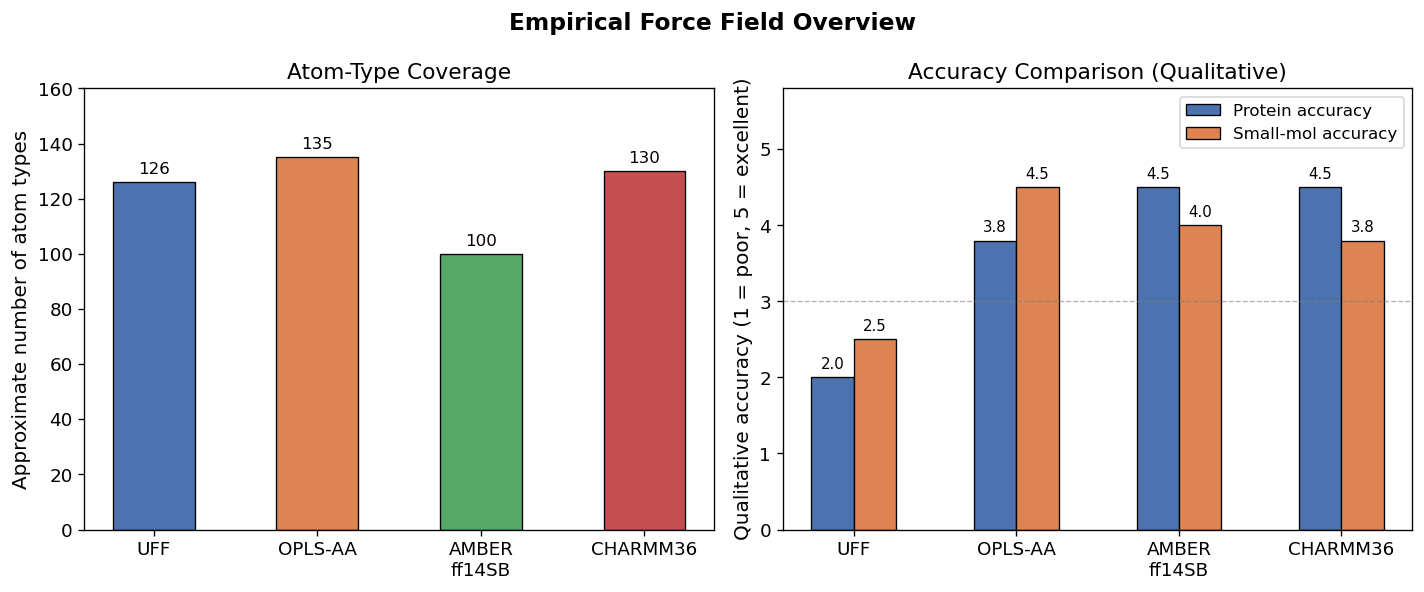

In [3]:
# Qualitative comparison of force fields across three metrics
ffs = ['UFF', 'OPLS-AA', 'AMBER\nff14SB', 'CHARMM36']

# Approximate/representative values (qualitative, 1-5 scale or count)
atom_types   = [126, 135, 100, 130]   # ~number of atom types
prot_acc     = [2.0, 3.8, 4.5, 4.5]  # accuracy for proteins (1-5)
sm_acc       = [2.5, 4.5, 4.0, 3.8]  # accuracy for small molecules (1-5)

x = np.arange(len(ffs))
width = 0.26

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: atom type coverage
ax = axes[0]
bars = ax.bar(x, atom_types, width=0.5, color=['#4C72B0','#DD8452','#55A868','#C44E52'],
              edgecolor='k', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(ffs)
ax.set_ylabel('Approximate number of atom types')
ax.set_title('Atom-Type Coverage')
ax.set_ylim(0, 160)
for bar, v in zip(bars, atom_types):
    ax.text(bar.get_x()+bar.get_width()/2, v+2, str(v), ha='center', va='bottom', fontsize=10)

# Right: accuracy scores
ax2 = axes[1]
b1 = ax2.bar(x - width/2, prot_acc, width, label='Protein accuracy', color='#4C72B0',
             edgecolor='k', linewidth=0.8)
b2 = ax2.bar(x + width/2, sm_acc,   width, label='Small-mol accuracy', color='#DD8452',
             edgecolor='k', linewidth=0.8)
ax2.set_xticks(x); ax2.set_xticklabels(ffs)
ax2.set_ylabel('Qualitative accuracy (1 = poor, 5 = excellent)')
ax2.set_title('Accuracy Comparison (Qualitative)')
ax2.set_ylim(0, 5.8)
ax2.legend()
ax2.axhline(3, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
for bar, v in zip(list(b1)+list(b2), prot_acc+sm_acc):
    ax2.text(bar.get_x()+bar.get_width()/2, v+0.07, f'{v}', ha='center', va='bottom', fontsize=9)

fig.suptitle('Empirical Force Field Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 2 — Periodic Boundary Conditions (PBC)

### 2.1 Why Do We Need PBC?

A finite simulation box has surfaces.  The fraction of atoms near the surface scales as:

$$f_\text{surface} \propto N^{-1/3}$$

| N | $f_\text{surface}$ |
|---|---|
| 1 000 | ≈ 30 % |
| 10 000 | ≈ 14 % |
| 1 000 000 | ≈ 1.4 % |

Surface atoms have different coordination, density, and dynamics — they dominate small simulations and introduce unphysical artefacts.  **Periodic Boundary Conditions (PBC)** replace the finite box with an infinite lattice of identical image boxes, eliminating all surfaces.

**Key constraints:**
- The box must be **larger than twice the cutoff**: $L > 2 r_\text{cut}$,  otherwise a particle can interact with its own image.
- *Image-charge artefacts* arise for charged systems in small boxes — Ewald summation / PME correct for this.


### 2.2 Cubic Box PBC — Wrapping and Images

For a cubic box of side length $L$, atom positions are defined in $[0, L)^3$ (or equivalently $[-L/2, L/2)^3$).

**Coordinate wrapping** (keeping atoms inside the box):

$$r_i \leftarrow r_i - L\,\lfloor r_i / L \rfloor$$

**Minimum image displacement** (shortest vector between two atoms):

$$\Delta \mathbf{r} = \mathbf{r}_j - \mathbf{r}_i$$
$$\Delta r_\alpha \leftarrow \Delta r_\alpha - L\,\text{round}\!\left(\frac{\Delta r_\alpha}{L}\right)\quad \text{for each component } \alpha \in \{x,y,z\}$$

**2D schematic:** imagine a 3×3 tiling of the simulation box.  Each box contains identical copies of every particle.  For the pair (i, j) in the central box, we find the image of j that is closest to i — that is the minimum-image vector.

For **non-orthogonal (triclinic) boxes**, wrap via the fractional-coordinate transformation: $\mathbf{s} = \mathbf{H}^{-1}\mathbf{r}$, apply wrapping in fractional space, then transform back.


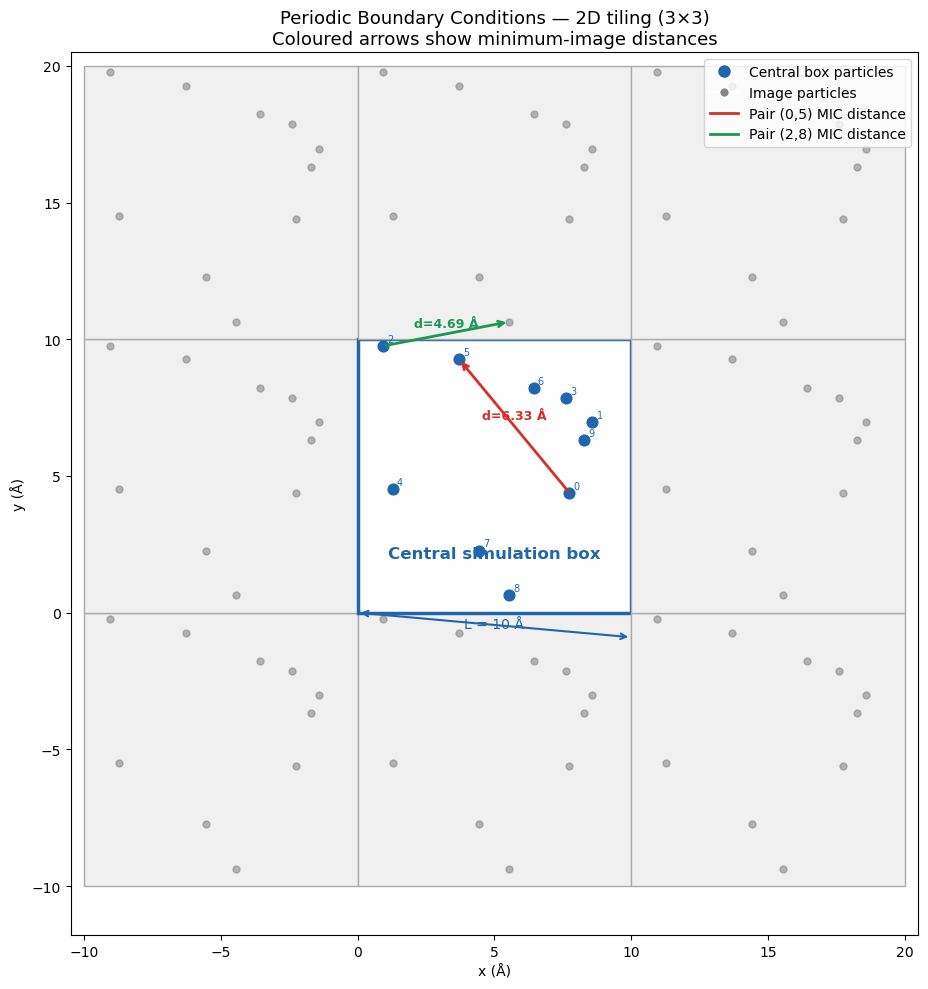

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D
# Visualise PBC tiling in 2D
rng = np.random.default_rng(42)
L, N = 10.0, 10
pos = rng.uniform(0, L, size=(N, 2))   # particles in central box

fig, ax = plt.subplots(figsize=(10, 10))

# Draw 3×3 tiling (-1, 0, +1 in each direction)
for nx in range(-1, 2):
    for ny in range(-1, 2):
        ox, oy = nx * L, ny * L
        is_central = (nx == 0 and ny == 0)
        fc = 'white' if is_central else '#f0f0f0'
        ec = '#2166ac' if is_central else '#aaaaaa'
        lw = 2.5 if is_central else 1.0
        rect = patches.Rectangle((ox, oy), L, L,
                                   linewidth=lw, edgecolor=ec,
                                   facecolor=fc, zorder=1)
        ax.add_patch(rect)
        # Image particles
        img_pos = pos + np.array([ox, oy])
        color = '#2166ac' if is_central else '#888888'
        ms = 60 if is_central else 25
        ax.scatter(img_pos[:, 0], img_pos[:, 1], s=ms, c=color,
                   zorder=3, alpha=1.0 if is_central else 0.6)
        if is_central:
            for k, (px, py) in enumerate(img_pos):
                ax.text(px + 0.15, py + 0.15, str(k), fontsize=7, color='#2166ac', zorder=4)

# Draw minimum-image distances for two pairs
pairs = [(0, 5), (2, 8)]
pair_colors = ['#d73027', '#1a9850']
for (i, j), col in zip(pairs, pair_colors):
    ri = pos[i]; rj = pos[j]
    dr = rj - ri
    dr_mic = dr - L * np.round(dr / L)
    rj_img = ri + dr_mic
    ax.annotate('', xy=rj_img, xytext=ri,
                arrowprops=dict(arrowstyle='->', color=col, lw=2.0))
    mid = (ri + rj_img) / 2
    ax.text(mid[0], mid[1]+0.25,
            f'd={np.linalg.norm(dr_mic):.2f} Å',
            color=col, fontsize=9, ha='center', fontweight='bold')

# Annotate central box
ax.text(L/2, 2, 'Central simulation box', ha='center', fontsize=12,
        color='#2166ac', fontweight='bold')
ax.annotate('', xy=(0, -0), xytext=(L, -0.9),
            arrowprops=dict(arrowstyle='<->', color='#2166ac', lw=1.5))
ax.text(L/2, -0.55, f'L = {L:.0f} Å', ha='center', fontsize=10, color='#2166ac')

ax.set_xlim(-L-0.5, 2*L+0.5); ax.set_ylim(-L-1.8, 2*L+0.5)
ax.set_aspect('equal')
ax.set_xlabel('x (Å)'); ax.set_ylabel('y (Å)')
ax.set_title('Periodic Boundary Conditions — 2D tiling (3×3)\n'
             'Coloured arrows show minimum-image distances', fontsize=13)

legend_elems = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#2166ac', markersize=10, label='Central box particles'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#888888', markersize=7,  label='Image particles'),
    Line2D([0],[0], color='#d73027', lw=2, label=f'Pair (0,5) MIC distance'),
    Line2D([0],[0], color='#1a9850', lw=2, label=f'Pair (2,8) MIC distance'),
]
ax.legend(handles=legend_elems, loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

---
## Section 3 — Minimum Image Convention (MIC)

### 3.1 Minimum Image Convention

For a pair of atoms (i, j) in a periodic box, there are infinitely many periodic images of j.  We always use the **closest** image:

$$\Delta\mathbf{r} = \mathbf{r}_j - \mathbf{r}_i$$
$$\Delta r_\alpha \leftarrow \Delta r_\alpha - L\,\text{round}\!\left(\frac{\Delta r_\alpha}{L}\right)\quad \alpha \in \{x,y,z\}$$
$$|\Delta\mathbf{r}_\text{MIC}| = \sqrt{\sum_\alpha \Delta r_\alpha^2}$$

**Validity condition:** this formula is only correct when the cutoff satisfies

$$r_\text{cut} < \frac{L}{2}$$

If this is violated, a particle can interact with more than one image of its neighbour, leading to double-counting.

**Non-orthogonal boxes (triclinic):** convert to fractional coordinates $\mathbf{s} = \mathbf{H}^{-1}\mathbf{r}$ (H = box matrix), apply MIC in fractional space ($\Delta s_\alpha \leftarrow \Delta s_\alpha - \text{round}(\Delta s_\alpha)$), then transform back: $\Delta\mathbf{r} = \mathbf{H}\,\Delta\mathbf{s}$.


### 3.2 Cutoff and Box-Size Relationship

| Interaction | Typical $r_\text{cut}$ | Box size needed ($L > 2r_\text{cut}$) |
|---|---|---|
| Lennard-Jones | 10–12 Å | > 20–24 Å |
| Short-range Coulomb | 10–12 Å | > 20–24 Å |
| PME (long-range part) | 10–12 Å (real-space) | > 20 Å |

**Impact on cost:**  
Larger $r_\text{cut}$ → larger box needed → more atoms → wall-clock time scales roughly as $O(N^2)$ or $O(N \log N)$ (PME).  Ewald summation / PME handle the long-range $1/r$ tail with $O(N \log N)$ cost, removing the need for an explicit long cutoff on electrostatics.

**Rule of thumb:** solvate with at least 10 Å of water on each side of the solute ⇒ box dimension $L \approx d_\text{solute} + 20\,\text{Å}$.


In [6]:
def min_image_dist(r1, r2, L):
    """3D minimum-image distance between r1 and r2 in a cubic box of side L."""
    dr = np.asarray(r2, dtype=float) - np.asarray(r1, dtype=float)
    dr -= L * np.round(dr / L)
    return np.sqrt(np.dot(dr, dr))


def naive_dist(r1, r2):
    dr = np.asarray(r2, dtype=float) - np.asarray(r1, dtype=float)
    return np.linalg.norm(dr)


L = 10.0
test_cases = [
    ([1.0, 1.0, 1.0], [2.0, 2.0, 2.0], 'Same side, close'),
    ([0.5, 0.5, 0.5], [9.5, 9.5, 9.5], 'Opposite corners — MIC shorter'),
    ([0.1, 5.0, 5.0], [9.9, 5.0, 5.0], 'Near x-boundary'),
    ([0.0, 0.0, 0.0], [5.0, 5.0, 5.0], 'Exact half-box'),
    ([2.0, 3.0, 4.0], [7.0, 3.0, 4.0], 'x-separation = L/2'),
    ([1.0, 2.0, 3.0], [8.5, 9.0, 2.0], 'Random pair across boundary'),
]

header = f"{'Description':<35} {'Naive dist (Å)':>16} {'MIC dist (Å)':>14}"
print(header)
print('-' * len(header))
for r1, r2, desc in test_cases:
    d_naive = naive_dist(r1, r2)
    d_mic   = min_image_dist(r1, r2, L)
    flag = '  ← shorter' if d_mic < d_naive - 1e-9 else ''
    print(f"{desc:<35} {d_naive:>16.4f} {d_mic:>14.4f}{flag}")

Description                           Naive dist (Å)   MIC dist (Å)
-------------------------------------------------------------------
Same side, close                              1.7321         1.7321
Opposite corners — MIC shorter               15.5885         1.7321  ← shorter
Near x-boundary                               9.8000         0.2000  ← shorter
Exact half-box                                8.6603         8.6603
x-separation = L/2                            5.0000         5.0000
Random pair across boundary                  10.3078         4.0311  ← shorter


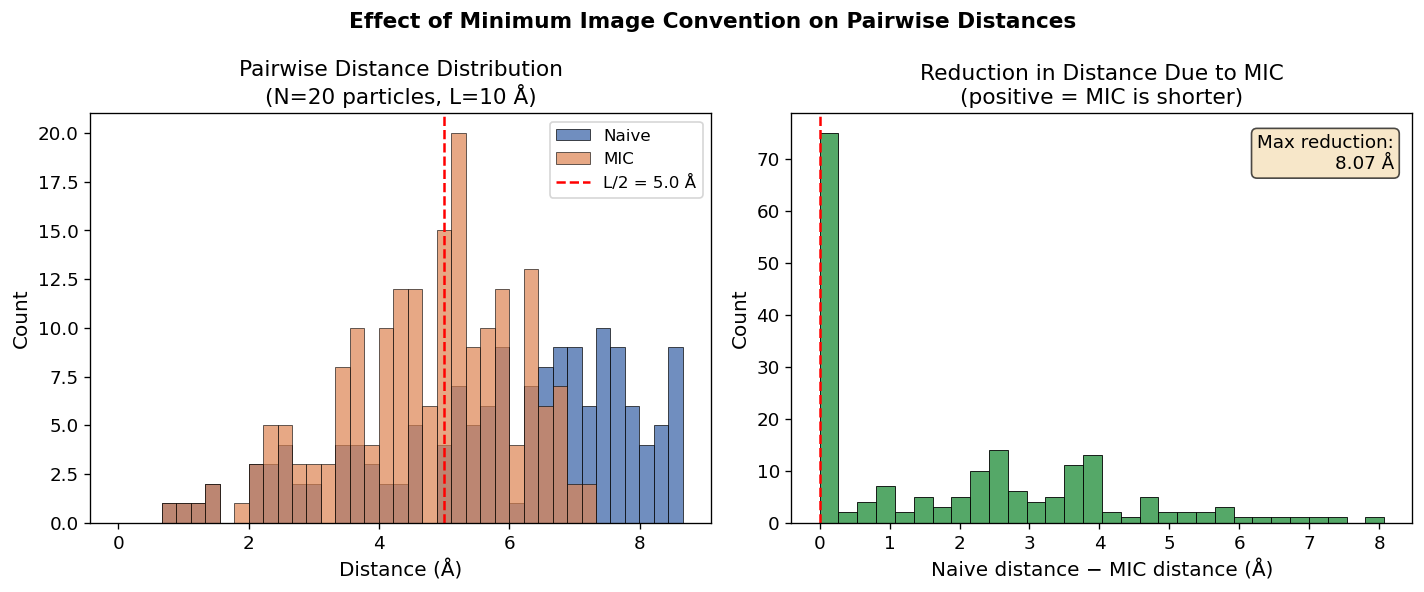

Total pairs: 190
Pairs shortened by MIC: 119 (62.6%)


In [7]:
# Compare pairwise distance distributions with and without MIC
rng = np.random.default_rng(42)
L, N = 10.0, 20
pos = rng.uniform(0, L, size=(N, 3))

naive_dists = []
mic_dists   = []
for i in range(N):
    for j in range(i+1, N):
        naive_dists.append(naive_dist(pos[i], pos[j]))
        mic_dists.append(min_image_dist(pos[i], pos[j], L))

naive_dists = np.array(naive_dists)
mic_dists   = np.array(mic_dists)

bins = np.linspace(0, L*np.sqrt(3)/2, 40)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.hist(naive_dists, bins=bins, color='#4C72B0', edgecolor='k', linewidth=0.5,
        alpha=0.8, label='Naive')
ax.hist(mic_dists,   bins=bins, color='#DD8452', edgecolor='k', linewidth=0.5,
        alpha=0.7, label='MIC')
ax.axvline(L/2, color='red', linestyle='--', label=f'L/2 = {L/2:.1f} Å')
ax.set_xlabel('Distance (Å)'); ax.set_ylabel('Count')
ax.set_title('Pairwise Distance Distribution\n(N=20 particles, L=10 Å)')
ax.legend()

ax2 = axes[1]
diff = naive_dists - mic_dists
ax2.hist(diff, bins=30, color='#55A868', edgecolor='k', linewidth=0.5)
ax2.axvline(0, color='red', linestyle='--')
ax2.set_xlabel('Naive distance − MIC distance (Å)')
ax2.set_ylabel('Count')
ax2.set_title('Reduction in Distance Due to MIC\n(positive = MIC is shorter)')
ax2.text(0.97, 0.95, f'Max reduction:\n{diff.max():.2f} Å',
         transform=ax2.transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.suptitle('Effect of Minimum Image Convention on Pairwise Distances', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Total pairs: {len(mic_dists)}')
print(f'Pairs shortened by MIC: {(diff > 1e-9).sum()} ({100*(diff>1e-9).mean():.1f}%)')

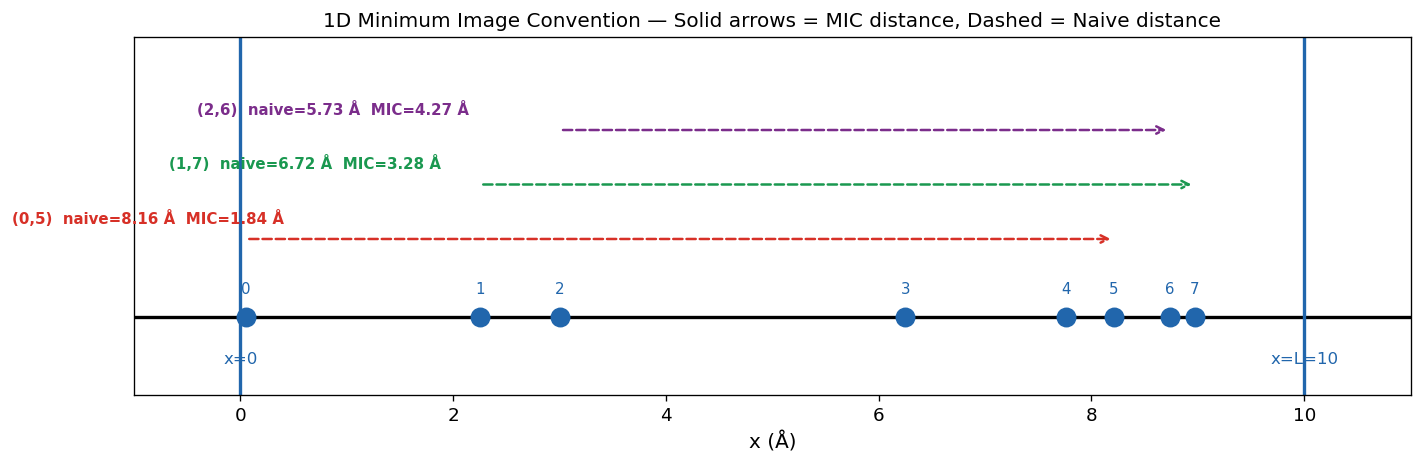

In [8]:
# 1D analogue: visualise MIC on a ring of length L
rng = np.random.default_rng(7)
L1D = 10.0
n1d = 8
x1d = np.sort(rng.uniform(0, L1D, n1d))

highlight_pairs = [(0, 5), (1, 7), (2, 6)]
pair_cols = ['#d73027', '#1a9850', '#7B2D8B']

fig, ax = plt.subplots(figsize=(12, 4))
ax.axhline(0, color='k', lw=2)
ax.axvline(0,   color='#2166ac', lw=2, linestyle='-')
ax.axvline(L1D, color='#2166ac', lw=2, linestyle='-')

# Particles
ax.scatter(x1d, np.zeros(n1d), s=120, zorder=5, c='#2166ac')
for k, xi in enumerate(x1d):
    ax.text(xi, 0.15, str(k), ha='center', fontsize=9, color='#2166ac')

y_offsets = [0.5, 0.85, 1.2]
for (i, j), col, yoff in zip(highlight_pairs, pair_cols, y_offsets):
    xi, xj = x1d[i], x1d[j]
    dx = xj - xi
    dx_mic = dx - L1D * np.round(dx / L1D)
    xj_img = xi + dx_mic

    # naive arrow
    ax.annotate('', xy=(xj, yoff), xytext=(xi, yoff),
                arrowprops=dict(arrowstyle='->', color=col, lw=1.5, linestyle='dashed'))
    # MIC arrow
    ax.annotate('', xy=(xj_img, yoff-0.18), xytext=(xi, yoff-0.18),
                arrowprops=dict(arrowstyle='->', color=col, lw=2.5))

    label_x = (xi + xj_img) / 2
    ax.text(label_x, yoff+0.1,
            f'({i},{j})  naive={abs(dx):.2f} Å  MIC={abs(dx_mic):.2f} Å',
            ha='center', fontsize=9, color=col, fontweight='bold')

ax.set_xlim(-1, L1D+1)
ax.set_ylim(-0.5, 1.8)
ax.set_xlabel('x (Å)')
ax.set_yticks([])
ax.set_title('1D Minimum Image Convention — Solid arrows = MIC distance, Dashed = Naive distance',
             fontsize=12)
ax.text(0,   -0.3, 'x=0', ha='center', color='#2166ac', fontsize=10)
ax.text(L1D, -0.3, f'x=L={L1D:.0f}', ha='center', color='#2166ac', fontsize=10)
plt.tight_layout()
plt.show()

---
## Section 4 — Neighbor Lists

### 4.1 Neighbor Lists

Naïvely computing all pairwise forces requires $O(N^2)$ operations — prohibitive for large N.

**Verlet neighbor list:**
- Store all pairs (i,j) with $r_{ij} < r_\text{cut} + r_\text{skin}$.
- On force evaluation, only loop over stored pairs.
- Rebuild every $\sim$20 steps, or when any atom has displaced > $r_\text{skin}/2$.
- Scales as $O(N)$ on average if $r_\text{cut}$ is small relative to $L$.

**Cell (linked) list:**
- Divide simulation box into cubic cells of side $\geq r_\text{cut}$.
- For each cell, only search 27 neighbouring cells (3×3×3).
- Build cost: $O(N)$; search cost: $O(N)$.
- Memory-efficient and cache-friendly.

**Combined (cell + Verlet):**  Build Verlet list using cell list for fast neighbour finding, rebuild less frequently.

| Method | Build cost | Force eval cost | Notes |
|---|---|---|---|
| Naïve | — | $O(N^2)$ | Only for N < ~500 |
| Verlet list | $O(N^2)$ or $O(N)$ with cells | $O(N)$ | Standard in MD codes |
| Cell list | $O(N)$ | $O(N)$ | No large buffer needed |


In [9]:
# Simple cell-list neighbor search in 2D with MIC

def build_cell_neighbor_list(pos2d, L, r_cut):
    """Return list of neighbor pairs using a 2D cell list."""
    n_cells = max(1, int(L / r_cut))
    cell_size = L / n_cells
    # Assign particles to cells
    cells = {}
    for idx, (x, y) in enumerate(pos2d):
        cx = int(x / cell_size) % n_cells
        cy = int(y / cell_size) % n_cells
        cells.setdefault((cx, cy), []).append(idx)
    # Build neighbor list
    neighbor_list = [[] for _ in range(len(pos2d))]
    for (cx, cy), members in cells.items():
        for dcx in range(-1, 2):
            for dcy in range(-1, 2):
                ncx = (cx + dcx) % n_cells
                ncy = (cy + dcy) % n_cells
                for i in members:
                    for j in cells.get((ncx, ncy), []):
                        if j <= i:
                            continue
                        dr = pos2d[j] - pos2d[i]
                        dr -= L * np.round(dr / L)
                        if np.dot(dr, dr) < r_cut**2:
                            neighbor_list[i].append(j)
                            neighbor_list[j].append(i)
    return neighbor_list


rng = np.random.default_rng(42)
L2, N2, r_cut2 = 20.0, 50, 5.0
pos2d = rng.uniform(0, L2, size=(N2, 2))

nbr_list = build_cell_neighbor_list(pos2d, L2, r_cut2)
n_neighbors = np.array([len(nb) for nb in nbr_list])

# Count force evaluations
pairs_naive     = N2 * (N2 - 1) // 2
pairs_cell_list = sum(n_neighbors) // 2
print(f'Particles:         {N2}')
print(f'r_cut:             {r_cut2} Å   L: {L2} Å')
print(f'Naïve pairs:       {pairs_naive}')
print(f'Cell-list pairs:   {pairs_cell_list}')
print(f'Speedup factor:    {pairs_naive/pairs_cell_list:.1f}x')
print(f'Avg neighbors/particle: {n_neighbors.mean():.1f}')

Particles:         50
r_cut:             5.0 Å   L: 20.0 Å
Naïve pairs:       1225
Cell-list pairs:   213
Speedup factor:    5.8x
Avg neighbors/particle: 8.5


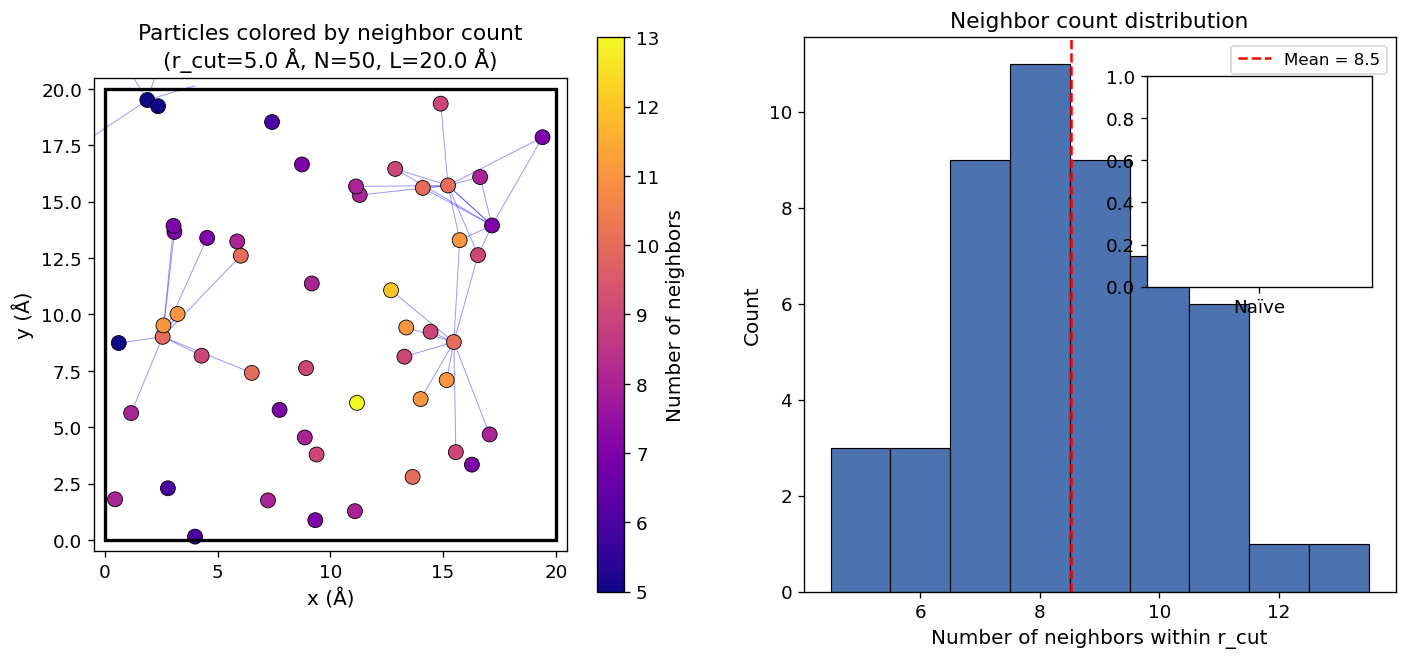

In [10]:
# Plot particles coloured by number of neighbors
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: scatter coloured by neighbor count
ax = axes[0]
sc = ax.scatter(pos2d[:, 0], pos2d[:, 1],
                c=n_neighbors, cmap='plasma', s=80,
                edgecolors='k', linewidth=0.5, zorder=3)
plt.colorbar(sc, ax=ax, label='Number of neighbors')

# Draw neighbor connections for a few particles
for i in range(min(5, N2)):
    for j in nbr_list[i]:
        dr = pos2d[j] - pos2d[i]
        dr -= L2 * np.round(dr / L2)
        rj_img = pos2d[i] + dr
        ax.plot([pos2d[i,0], rj_img[0]], [pos2d[i,1], rj_img[1]],
                'b-', lw=0.6, alpha=0.4, zorder=1)

rect = patches.Rectangle((0,0), L2, L2, linewidth=2,
                           edgecolor='k', facecolor='none', zorder=4)
ax.add_patch(rect)
ax.set_xlim(-0.5, L2+0.5); ax.set_ylim(-0.5, L2+0.5)
ax.set_aspect('equal')
ax.set_xlabel('x (Å)'); ax.set_ylabel('y (Å)')
ax.set_title(f'Particles colored by neighbor count\n(r_cut={r_cut2} Å, N={N2}, L={L2} Å)')

# Right: histogram of neighbor counts + pair comparison
ax2 = axes[1]
bins_n = np.arange(n_neighbors.min()-0.5, n_neighbors.max()+1.5)
ax2.hist(n_neighbors, bins=bins_n, color='#4C72B0', edgecolor='k', linewidth=0.7)
ax2.set_xlabel('Number of neighbors within r_cut')
ax2.set_ylabel('Count')
ax2.set_title('Neighbor count distribution')
ax2.axvline(n_neighbors.mean(), color='red', linestyle='--',
            label=f'Mean = {n_neighbors.mean():.1f}')
ax2.legend()

# Inset: naïve vs cell-list pairs bar chart
ax_ins = ax2.inset_axes([0.58, 0.55, 0.38, 0.38])
ax_ins.bar(['Naïve', 'Cell list'], [pairs_naive, pairs_cell_list],
           color=['#DD8452','#55A868'], edgecolor='k', linewidth=0.8)
ax_ins.set_ylabel('Pairs', fontsize=8)
ax_ins.set_title('Evaluation cost', fontsize=8)
ax_ins.tick_params(labelsize=8)

plt.suptitle('Cell-List Neighbor List — 2D Demo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

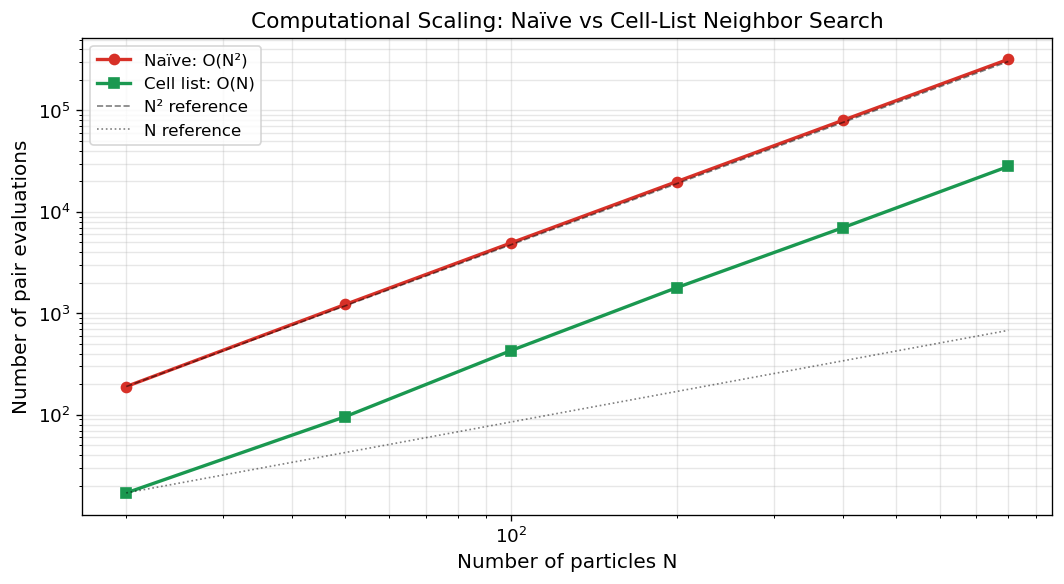

In [11]:
# Demonstrate O(N) vs O(N²) scaling
import time

Ns = [20, 50, 100, 200, 400, 800]
naive_counts = []
cell_counts  = []

rng = np.random.default_rng(0)
L_demo, r_demo = 30.0, 5.0

for Nd in Ns:
    pos_d = rng.uniform(0, L_demo, size=(Nd, 2))
    naive_counts.append(Nd * (Nd - 1) // 2)
    nb = build_cell_neighbor_list(pos_d, L_demo, r_demo)
    cell_counts.append(sum(len(x) for x in nb) // 2)

Ns_arr = np.array(Ns, dtype=float)
fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(Ns_arr, naive_counts, 'o-', color='#d73027', label='Naïve: O(N²)', lw=2)
ax.loglog(Ns_arr, cell_counts,  's-', color='#1a9850', label='Cell list: O(N)', lw=2)

# Reference lines
ref_n2 = Ns_arr**2 / Ns_arr[0]**2 * naive_counts[0]
ref_n1 = Ns_arr / Ns_arr[0] * cell_counts[0]
ax.loglog(Ns_arr, ref_n2, 'k--', lw=1, alpha=0.5, label='N² reference')
ax.loglog(Ns_arr, ref_n1, 'k:',  lw=1, alpha=0.5, label='N reference')

ax.set_xlabel('Number of particles N')
ax.set_ylabel('Number of pair evaluations')
ax.set_title('Computational Scaling: Naïve vs Cell-List Neighbor Search')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

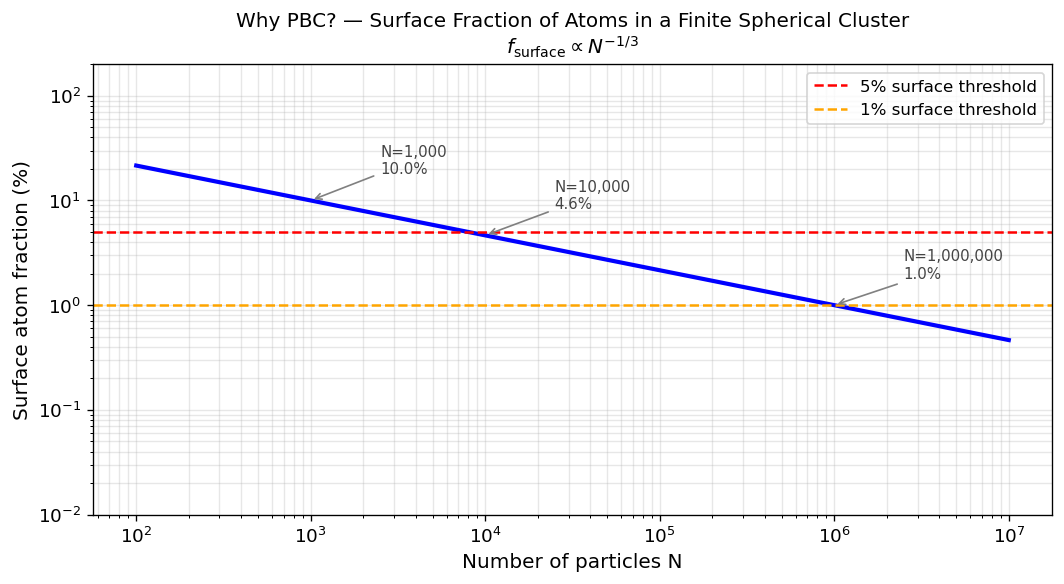

In [12]:
# Quantify surface-atom fraction and PBC benefit
Nvals = np.logspace(2, 7, 200)
f_surface = Nvals**(-1/3)

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(Nvals, f_surface * 100, 'b-', lw=2.5)
ax.axhline(5, color='red',    linestyle='--', lw=1.5, label='5% surface threshold')
ax.axhline(1, color='orange', linestyle='--', lw=1.5, label='1% surface threshold')

for N_mark in [1000, 10000, 1e6]:
    fs = N_mark**(-1/3) * 100
    ax.annotate(f'N={int(N_mark):,}\n{fs:.1f}%',
                xy=(N_mark, fs), xytext=(N_mark*2.5, fs*1.8),
                arrowprops=dict(arrowstyle='->', color='gray'),
                fontsize=9, color='#444444')

ax.set_xlabel('Number of particles N')
ax.set_ylabel('Surface atom fraction (%)')
ax.set_title('Why PBC? — Surface Fraction of Atoms in a Finite Spherical Cluster\n'
             r'$f_\mathrm{surface} \propto N^{-1/3}$', fontsize=12)
ax.legend()
ax.grid(True, which='both', alpha=0.3)
ax.set_ylim(0.01, 200)
plt.tight_layout()
plt.show()

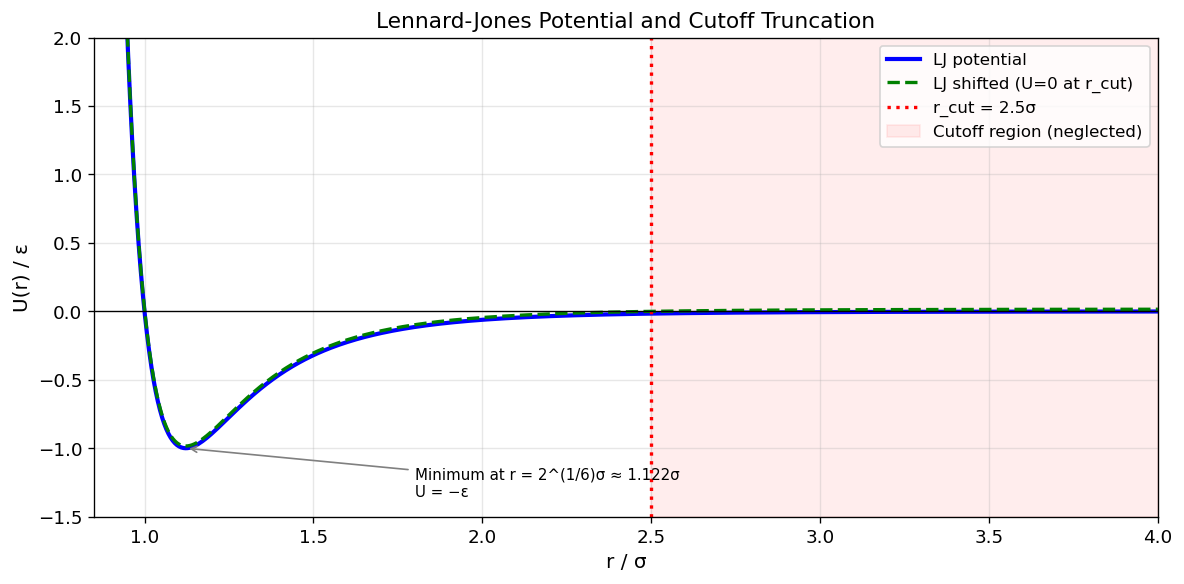

In [13]:
# Illustrate Lennard-Jones potential with and without cutoff
r = np.linspace(0.85, 4.0, 500)
eps, sig = 1.0, 1.0
r_cut_lj = 2.5  # in units of sigma

U_LJ = 4 * eps * ((sig/r)**12 - (sig/r)**6)

# Shift potential so U(r_cut)=0
U_cut = 4 * eps * ((sig/r_cut_lj)**12 - (sig/r_cut_lj)**6)
U_LJ_shifted = U_LJ - U_cut

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(r, U_LJ,         'b-',  lw=2.5, label='LJ potential')
ax.plot(r, U_LJ_shifted, 'g--', lw=2,   label='LJ shifted (U=0 at r_cut)')
ax.axvline(r_cut_lj, color='red', linestyle=':', lw=2,
           label=f'r_cut = {r_cut_lj}σ')
ax.axhline(0, color='k', lw=0.8)
ax.fill_betweenx([-1.5, 2], r_cut_lj, 4.0, alpha=0.07, color='red', label='Cutoff region (neglected)')

ax.set_xlim(0.85, 4.0)
ax.set_ylim(-1.5, 2.0)
ax.set_xlabel('r / σ')
ax.set_ylabel('U(r) / ε')
ax.set_title('Lennard-Jones Potential and Cutoff Truncation', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

# Annotate minimum
r_min = 2**(1/6) * sig
ax.annotate(f'Minimum at r = 2^(1/6)σ ≈ {r_min:.3f}σ\nU = −ε',
            xy=(r_min, -1.0), xytext=(1.8, -1.35),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9)
plt.tight_layout()
plt.show()

### 4.2 Long-Range Electrostatics — Ewald Summation & PME

Coulomb interactions decay as $1/r$ — they are **long-ranged** and cannot simply be truncated.  Ewald summation splits the potential into:

$$U_\text{Coulomb} = U_\text{short}(r) + U_\text{long}(\mathbf{k}) + U_\text{self}$$

- **Short-range part:** Screened by a Gaussian charge cloud; computed in real space with a cutoff.  
- **Long-range part:** The complementary Gaussian; computed in reciprocal ($k$-) space.  
- **Self term:** Corrects for self-interaction of each Gaussian with itself.

**Particle-Mesh Ewald (PME):** interpolates charges onto a grid, uses 3D FFT for the reciprocal-space sum — scales as $O(N \log N)$ vs $O(N^{3/2})$ for standard Ewald.  PME is the default in GROMACS, NAMD, AMBER, and CHARMM.

**Box size requirement for PME:** box dimensions typically $\geq 30$ Å for biological systems.


---
## Summary

### Force Fields
| | |
|---|---|
| **UFF** | Rule-based, full periodic table, best for inorganic/MOFs |
| **OPLS** | Optimised for liquid densities; strong for drug-like molecules |
| **AMBER** | RESP charges; gold standard for proteins & nucleic acids |
| **CHARMM** | Urey-Bradley + CMAP; excellent for membranes & proteins |

### Periodic Boundary Conditions
- Eliminate surface effects by tiling the simulation box infinitely.
- Constraint: $L > 2 r_\text{cut}$ (minimum image validity).
- Long-range electrostatics require PME/Ewald, not simple cutoff.

### Minimum Image Convention
- Always use the closest periodic image: $\Delta r_\alpha \leftarrow \Delta r_\alpha - L\,\text{round}(\Delta r_\alpha/L)$.
- For triclinic boxes, apply MIC in fractional coordinates.

### Neighbor Lists
- Reduce $O(N^2)$ force evaluations to $O(N)$ using cell lists or Verlet lists.
- Cell list: divide box into cells of size $r_\text{cut}$; search 27 adjacent cells.
- Verlet list: rebuild every ~20 steps; maintain skin buffer $r_\text{skin}$.


---
## References

1. Rappé, A. K. *et al.* UFF, a full periodic table force field for molecular mechanics and molecular dynamics simulations. *J. Am. Chem. Soc.* **114**, 10024–10035 (1992).
2. Jorgensen, W. L. *et al.* Development and testing of the OPLS all-atom force field. *J. Am. Chem. Soc.* **118**, 11225–11236 (1996).
3. Maier, J. A. *et al.* ff14SB: Improving the accuracy of protein side chain and backbone parameters from ff99SB. *J. Chem. Theory Comput.* **11**, 3696–3713 (2015).
4. Huang, J. & MacKerell, A. D. CHARMM36 all-atom additive protein force field: validation based on comparison to NMR data. *J. Comput. Chem.* **34**, 2135–2145 (2013).
5. Allen, M. P. & Tildesley, D. J. *Computer Simulation of Liquids* (2nd ed.). Oxford (2017).
6. Frenkel, D. & Smit, B. *Understanding Molecular Simulation* (3rd ed.). Academic Press (2023).
7. Essmann, U. *et al.* A smooth particle mesh Ewald method. *J. Chem. Phys.* **103**, 8577 (1995).
8. Verlet, L. Computer 'experiments' on classical fluids. *Phys. Rev.* **159**, 98 (1967).


---
## Exercises

1. **Force field choice:** You want to simulate a zinc-containing metal–organic framework (MOF). Which force field would you choose and why? What are its limitations?

2. **Box size:** A protein has a diameter of 40 Å. You want to use a cutoff of 12 Å and PME. What is the minimum cubic box dimension you should use? Why?

3. **MIC implementation:** Extend the `min_image_dist` function to handle a **triclinic** (non-orthogonal) box defined by the matrix $\mathbf{H}$. Test it with a box where the vectors are tilted by 30°.

4. **Neighbor list scaling:** Run the `build_cell_neighbor_list` function on N = 100, 500, 1000, 5000 particles and time each call. Plot wall-clock time vs N and verify O(N) scaling.

5. **PBC artefacts:** What happens if $r_\text{cut} > L/2$? Write a small simulation (two atoms in a 1D box) that demonstrates the double-counting problem.
